# Quickstart: Writing dynestyx models

This quickstart gives a fast and direct introduction to `dynestyx` for those who already know about Bayesian inference for dynamical systems. If you would like a more conceptual introduction, please see the [Mathematical Introduction](../../math_intro/). If you would like a step-by-step introduction to `NumPyro` and `dynestyx`, please see the [Gentle Introduction](../../tutorials/gentle_intro/00_index/). The tl;dr is that `dynestyx` is an extension of `numpyro` designed to make the specification and inference of dynamical systems simple, fast, and reproducible. In this notebook, we show how models are built in `dynestyx`, building upon an example of a simple linear, Gaussian dynamical system.

## In math

For this tutorial, the simple dynamical system we use a simple linear time-invariant (LTI) dynamical system, with linear, Gaussian observations. In particular, we have a two-dimensional state $x_t \in \mathbb{R}^2$ that evolves through a simple SDE that couples the two states via a parameter $\rho$.

We will place a uniform prior on $\rho$,
$$\rho \sim U(0.0, 5.0),$$
and specify the SDE as
$$dx_t = \underbrace{\begin{bmatrix} -1.0 & 0.0 \\ \rho & -1.0 \end{bmatrix}}_{A} x_t \, \mathrm{d}t + d\beta_t,$$
with unit covariance in the diffusion. Observations $y_t$ will be Gaussian-corrupted versions of $x_2$,

$$y_{t_k} = \underbrace{\begin{bmatrix} 0.0 \\ 1.0 \end{bmatrix}}_{H} x_{t_k} + \varepsilon_{t_k}; \qquad \varepsilon_{t} \sim \mathcal{N}(0.0, 1.0).$$

We will specify an initial condition $p(x_0) = \mathcal{N}(0.0, I)$.

## In code

To specify this system in `dynestyx`, we write it down as a `dynestyx.models.DynamicalModel` in part of a `numpyro` program, and then use `dsx.sample`. We'll also use the convenience class `dynestyx.models.LinearGaussianObservation` here, but this is not necessary, in principle.

In [2]:
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist

import dynestyx as dsx
from dynestyx import (
    ContinuousTimeStateEvolution,
    DynamicalModel,
    LinearGaussianObservation,
)


def continuous_time_lti_gaussian_model(
    rho=None, predict_times=None, obs_times=None, obs_values=None
):
    # Sample rho using normal numpyro sampling
    rho = numpyro.sample("rho", dist.Uniform(0.0, 5.0), obs=rho)

    # Create the dynamical model with sampled rho
    A = jnp.array([[-1.0, 0.0], [rho, -1.0]])

    dynamics = DynamicalModel(
        initial_condition=dist.MultivariateNormal(
            loc=jnp.zeros(2), covariance_matrix=1.0**2 * jnp.eye(2)
        ),
        state_evolution=ContinuousTimeStateEvolution(
            drift=lambda x, u, t: A @ x,
            diffusion_coefficient=lambda x, u, t: jnp.eye(2),
        ),
        observation_model=LinearGaussianObservation(
            H=jnp.array([[0.0, 1.0]]), R=jnp.array([[0.15**2]])
        ),
    )

    # Use dsx.sample to sample from the dynamical model
    return dsx.sample(
        "f",
        dynamics,
        predict_times=predict_times,
        obs_times=obs_times,
        obs_values=obs_values,
    )

## Simulating from the model

To generate from the generative model, we have to tell `dynestyx` *how* to simulate from the model. Pass `obs_times` (and optionally `ctrl_times`, `ctrl_values`) as kwargs to the model. We simulate with a `dsx.simulators.SDESimulator`:

In [3]:
import jax.random as jr
from numpyro.infer import Predictive

from dynestyx import SDESimulator

obs_times = jnp.arange(start=0.0, stop=100.0, step=0.01)

prng_key = jr.PRNGKey(0)
sde_solver_key, predictive_key = jr.split(prng_key, 2)

predictive_model = Predictive(continuous_time_lti_gaussian_model, num_samples=1)

with SDESimulator():
    synthetic_samples = predictive_model(
        predictive_key, rho=2.0, predict_times=obs_times
    )

The `samples` object now comprises a dictionary that contains all the outputs of the `numpyro` program:

In [4]:
synthetic_samples.keys()

# print the shapes of the variables
for k, v in synthetic_samples.items():
    print(k, v.shape)

f_observations (1, 1, 10000, 1)
f_states (1, 1, 10000, 2)
f_times (1, 1, 10000)
f_x_0 (1, 1, 2)
rho (1,)


In particular, `observations`, `states`, and `times` all correspond to our dynamical system.

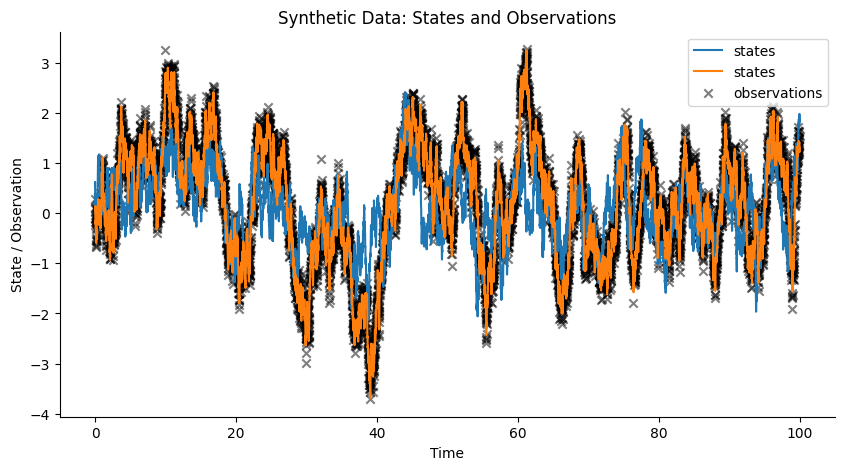

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

times = jnp.squeeze(synthetic_samples["f_times"])
states = jnp.squeeze(synthetic_samples["f_states"])
observations = jnp.squeeze(synthetic_samples["f_observations"])

plt.plot(times, states, label="states")
plt.scatter(
    times,
    observations,
    label="observations",
    marker="x",
    color="black",
    alpha=0.5,
)
plt.title("Synthetic Data: States and Observations")
plt.xlabel("Time")
plt.ylabel("State / Observation")
sns.despine()
plt.legend()
plt.show()

## Bayesian system identification

Performing Bayesian inference for system identification (in this case, obtaining posteriors of $\rho$) also becomes simple. Recall that to obtain posteriors of $\theta$, we must compute posteriors with respect to 

$$ p(\theta \mid y_{1:T}) \propto p(\theta) \underbrace{p(y_{1:T} \mid \theta)}_{\text{marginal likelihod}}. $$

We can accomplish this by appropriately **interpreting** the `dsx.sample(..)` statement. We will proceed with the normal numpyro tools, but wrap it in a `Filter` context for marginal likelihood computation. Inference over $\theta$ is then a standard Bayesian inference problem.

The `Filter` object gives us some control over the way we solve for the marginal likelihood, including the method and its hyperparameters. By default, we use an ensemble Kalman filter (EnKF); the EnKF is biased for nonlinear state space models, but still generally accurate for high-quality inference. To change the filtering method, pass a config, e.g. `Filter(filter_config=ContinuousTimeDPFConfig(n_particles=2500))`.

After specifying the marginal likelihood computation, inference can proceed in the standard way for `numpyro` (although, MCMC quality may vary based on what approximation to the marginal likelihood we take). The EnKF provides a very smooth marginal likelkhood, so we can often use NUTS in state space models that are not overly complex. 

In [6]:
from numpyro.infer import MCMC, NUTS

from dynestyx.inference.filters import Filter

obs_values = synthetic_samples["f_observations"][0, 0]  # shape (T, obs_dim)

mcmc_key = jr.PRNGKey(0)

with Filter():
    nuts_kernel = NUTS(continuous_time_lti_gaussian_model)
    mcmc = MCMC(nuts_kernel, num_samples=100, num_warmup=100)
    mcmc.run(mcmc_key, obs_times=times, obs_values=obs_values)

posterior_samples = mcmc.get_samples()

sample: 100%|██████████| 200/200 [07:39<00:00,  2.30s/it, 3 steps of size 1.02e+00. acc. prob=0.94]


Plotting the posterior values of $\rho$ shows a posterior centered at the true value of $2.0$.

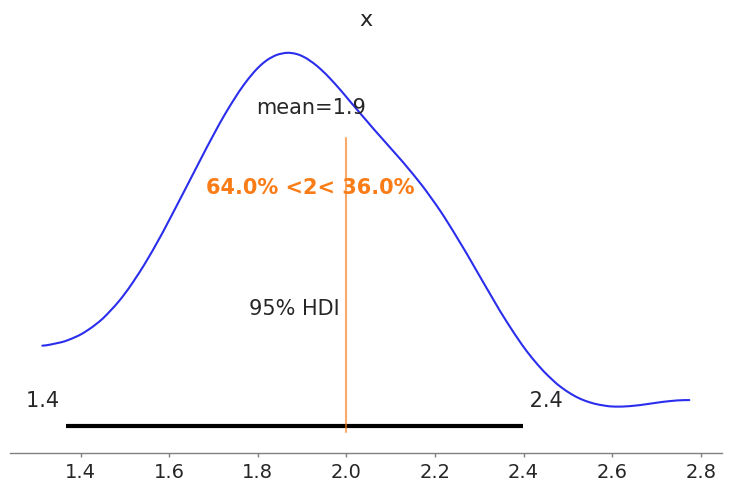

In [7]:
import arviz as az

az.style.use("arviz-white")

az.plot_posterior(posterior_samples["rho"], hdi_prob=0.95, ref_val=2.0)

plt.show()

## Likelihood sweep

As a quick diagnostic, we can sweep over fixed values of $\rho$ and evaluate the marginal log-likelihood $\log p(y_{1:T}\mid\rho)$ using the same `Filter`-based model. This is useful for checking identifiability and seeing whether the inferred posterior mode aligns with the likelihood peak.

/var/folders/28/rfdjbzgj0bz_x56whkjmhl600000gn/T/ipykernel_8806/2187872338.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


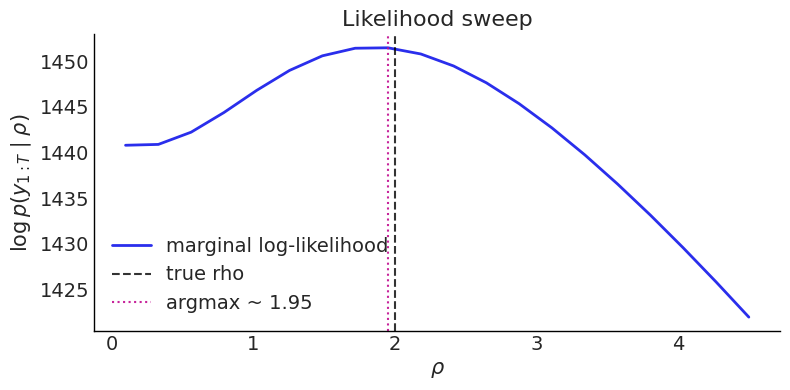

In [8]:
from numpyro.infer import Predictive

from dynestyx.inference.filters import Filter


def marginal_loglik_at_rho(rho_value, *, obs_times, obs_values):
    with Filter():
        predictive = Predictive(
            continuous_time_lti_gaussian_model,
            params={"rho": jnp.array(rho_value)},
            num_samples=1,
            exclude_deterministic=False,
        )
        out = predictive(jr.PRNGKey(123), obs_times=obs_times, obs_values=obs_values)
    # Keep this robust to scalar vs singleton-shaped return.
    return jnp.ravel(out["f_marginal_loglik"])[0]


rho_grid = jnp.linspace(0.1, 4.5, 20)
loglik_grid = jnp.array(
    [
        marginal_loglik_at_rho(r, obs_times=times, obs_values=obs_values)
        for r in rho_grid
    ]
)

rho_hat = rho_grid[jnp.argmax(loglik_grid)]

plt.figure(figsize=(8, 4))
plt.plot(rho_grid, loglik_grid, lw=2, label="marginal log-likelihood")
plt.axvline(2.0, ls="--", color="black", alpha=0.8, label="true rho")
plt.axvline(
    rho_hat, ls=":", color="C3", alpha=0.9, label=f"argmax ~ {float(rho_hat):.2f}"
)
plt.xlabel(r"$\rho$")
plt.ylabel(r"$\log p(y_{1:T}\mid\rho)$")
plt.title("Likelihood sweep")
plt.legend()
plt.tight_layout()
plt.show()